In [1]:
import torch
from torch import nn
import torch_geometric
from torch_geometric.nn import SAGEConv, GraphConv, GraphSAGE
import torch
import networkx as nx 
from torch.utils.data import Dataset, DataLoader
import pickle
import pdb 
import numpy as np
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import pandas as pd 
import pickle
import pdb
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj, subgraph, k_hop_subgraph
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'tools'))
from sklearn.neighbors import kneighbors_graph
from torch.optim.lr_scheduler import ReduceLROnPlateau
from ClassGraphDat import GraphDataset
torch.manual_seed(42)

In [2]:
# class GraphEncoderWithResidual(nn.Module):
#     def __init__(self, in_channels, hidden_channels, out_channels):
#         super(GraphEncoderWithResidual, self).__init__()
#         self.conv1 = SAGEConv(in_channels, hidden_channels*2)
#         self.bn1 = nn.BatchNorm1d(hidden_channels*2)
#         self.conv2 = SAGEConv(hidden_channels*2, hidden_channels)
#         self.bn2 = nn.BatchNorm1d(hidden_channels)
#         self.lin = nn.Linear(hidden_channels, out_channels)
#         self.shortcut = nn.Linear(in_channels, out_channels)

#     def forward(self, x, edge_index):
#         identity = self.shortcut(x)
#         x = F.relu(self.bn1(self.conv1(x, edge_index)))
#         x = F.relu(self.bn2(self.conv2(x, edge_index)))
#         x = self.lin(x)
#         x += identity
#         return x


class GraphEncoderWithResidual(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphEncoderWithResidual, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels*2)
        self.conv2 = SAGEConv(hidden_channels*2, hidden_channels)
        # self.conv3 = SAGEConv(hidden_channels, out_channels)
        self.lin = nn.Linear(hidden_channels, out_channels)
        # Linear transformation to match dimensions for residual connection
        self.shortcut = nn.Linear(in_channels, out_channels)
        # self.sm = nn.Softmax(dim=1)

    def forward(self, x, edge_index):
        identity = x
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        # x = self.conv3(x, edge_index)
        x = self.lin(x)
        # Applying shortcut and adding it to the output of conv3
        identity = self.shortcut(identity)
        x += identity  # Element-wise addition
        # print('before: ', x[0])
        # print(np.shape(x))
        # x = self.sm(x)
        # print('after: ', x[0])
        return x

In [23]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)  # Prevents nans when the loss is zero
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return torch.mean(F_loss)

focal_loss = FocalLoss(alpha=0.25, gamma=2.0)

# Assuming a loss function appropriate for node feature reconstruction, e.g., MSE for continuous features
def loss_function(reconstructed_x, original_x):

    # print(/)
    # bce_loss_fn = torch.nn.BCEWithLogitsLoss()
    # loss = bce_loss_fn(logits, one_hot_targets)
    weights = torch.tensor([ 662843/17722.0,  662843/49808.0, 662843/209018.0, 662843/386295.0], dtype=torch.float)
    weights = weights/torch.sum(weights)
    return F.cross_entropy(reconstructed_x, original_x, weight=weights, label_smoothing=0.2)

# bce_loss_fn = torch.nn.BCEWithLogitsLoss()
# loss = bce_loss_fn(logits, one_hot_targets)
# print(loss) 

def cosine_loss(adj, emb):
    norms = torch.norm(emb, p=2, dim=1, keepdim=True)
    normalized_embeddings = emb / norms.clamp(min=1e-4)
    cosine_similarity_matrix = torch.mm(normalized_embeddings, normalized_embeddings.t())
    target_adjacency = torch.zeros_like(cosine_similarity_matrix)
    target_adjacency[adj[0], adj[1]] = 1
    # Directly using logits; no need to apply sigmoid.
    return F.binary_cross_entropy_with_logits(cosine_similarity_matrix, target_adjacency)

In [24]:
def train(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0
    embeddings = []
    origs = []
    # lossfunc = nn.CrossEntropyLoss()
    # print(data_loader)
    for data in data_loader:
        optimizer.zero_grad()
        embed = model(data[0][0].to(device), data[1][0].to(device))
        # origs.append(data[0][0].detach())
        # print(np.shape(embed), np.shape(data[2][0]))
        # print()
        # print(data[2][0][0], embed[0].detach())
        # loss = lossfunc(embed, data[2][0].to(device))
        # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))
        # print()
        # print(data[2][0], np.shape(embed), np.shape(data[2][0]))
        loss = loss_function(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
        # loss = focal_loss(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        # embeddings.append(embed.detach())
        # print(total_loss)
    return total_loss / len(data_loader), embeddings, origs

In [25]:
folder_graph = './classGraphs/'
device = "cpu"
# fname = 'small_graphs.pth'
files = os.listdir(folder_graph)
files = [file for file in files if file.endswith('.pickle')]
hC = 40
inC = 100

dataset = GraphDataset(folder_graph, files)

dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=8)
actuals = []
final_loss = []
embeddings = []
outchannels = 4
model = GraphEncoderWithResidual(in_channels=inC, hidden_channels=hC, out_channels=outchannels).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
# scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
losses = []
embeds = []
acts = []
for epoch in range(1, 5):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
    # scheduler.step(loss)
# epoch_loss = loss / len(dataloader)
# embeddings.append(embeds)
# final_loss.append(losses)
# actuals.append(acts)

# Assuming encoder and decoder are your model's components
encoder_state_dict = model.state_dict()
# decoder_state_dict = model.decoder.state_dict()
# Save the state dictionaries
torch.save(encoder_state_dict, './LinClassOneHot_encoder_state_dict'+str(outchannels)+'.pth')
# torch.save(decoder_state_dict, './CDC/decoder_state_dict'+str(outchannels)+'.pth')
        # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))


Epoch 1, Loss: 2.1724
Epoch 2, Loss: 2.1715
Epoch 3, Loss: 2.1725
Epoch 4, Loss: 2.1723


In [27]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(1, 5):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)

encoder_state_dict = model.state_dict()
torch.save(encoder_state_dict, './LinClassOneHot_encoder_state_dict'+str(outchannels)+'.pth')


Epoch 1, Loss: 2.1193
Epoch 2, Loss: 2.1193
Epoch 3, Loss: 2.1192
Epoch 4, Loss: 2.1194


In [28]:
optimizer = optim.Adam(model.parameters(), lr=0.0001)

for epoch in range(1, 5):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)

encoder_state_dict = model.state_dict()
torch.save(encoder_state_dict, './LinClassOneHot_encoder_state_dict'+str(outchannels)+'.pth')

Epoch 1, Loss: 2.1143
Epoch 2, Loss: 2.1143
Epoch 3, Loss: 2.1143
Epoch 4, Loss: 2.1143


In [39]:
# sf = nn.Softmax(dim=1)
# x = torch.tensor([[-0.5207, -0.6732,  0.1790, -0.5166], [-0.3699, -0.7055, -0.0155, -0.2880]])
# print(np.shape(x))
# print(sf(x))

In [16]:
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'sim'))

In [17]:
from params import ENVIRONMENT_BOUNDARY_X, COMMIT_THRESHOLD
from sklearn.neighbors import kneighbors_graph
from scipy.spatial import ConvexHull
MAX_DIST=ENVIRONMENT_BOUNDARY_X[-1]

torch.manual_seed(42)

# class GraphEncoderWithResidual(nn.Module):
#     def __init__(self, in_channels, hidden_channels, out_channels):
#         super(GraphEncoderWithResidual, self).__init__()
#         self.conv1 = SAGEConv(in_channels, hidden_channels*2)
#         self.conv2 = SAGEConv(hidden_channels*2, hidden_channels)
#         # self.conv3 = SAGEConv(hidden_channels, out_channels)
#         self.lin = nn.Linear(hidden_channels, out_channels)
#         # Linear transformation to match dimensions for residual connection
#         self.shortcut = nn.Linear(in_channels, out_channels)
#         # self.sm = nn.Softmax(dim=1)

#     def forward(self, x, edge_index):
#         identity = x
#         x = F.relu(self.conv1(x, edge_index))
#         x = F.relu(self.conv2(x, edge_index))
#         # x = self.conv3(x, edge_index)
#         x = self.lin(x)
#         # Applying shortcut and adding it to the output of conv3
#         identity = self.shortcut(identity)
#         x += identity  # Element-wise addition
#         # print('before: ', x[0])
#         # print(np.shape(x))
#         # x = self.sm(x)
#         # print('after: ', x[0])
#         return x
    
    


# def node_to_color_black(node):
#     if node[9] == 0.0:
#         return True
#     else:
#         return False

# def node_to_color_green(node, quals):
#     # pdb.set_trace()
#     nA = np.sum([1 for _ in node[0::10]])
#     dancers = [(1, q) for a, q in zip(node[0::10], node[9::10]) if a == 1]
#     qs = [0]*4
#     # pdb.set_trace()
#     for d in dancers:
#         ii = quals.index(d[1])
#         qs[ii] += 1

#     if np.max(qs) > COMMIT_THRESHOLD*nA:
#         id = np.argmax(qs)
#         if quals[id] == np.max(quals):
#             return True
#         else:
#             return False
#     else:
#         return False
    
# def node_to_color_red(node, quals):
#     # pdb.set_trace()
#     nA = np.sum([1 for _ in node[0::10]])
#     dancers = [(1, q) for a, q in zip(node[0::10], node[9::10]) if a == 1]
#     qs = [0]*4
#     # pdb.set_trace()
#     for d in dancers:
#         ii = quals.index(d[1])
#         qs[ii] += 1

#     if np.max(qs) > COMMIT_THRESHOLD*nA:
#         id = np.argmax(qs)
#         if quals[id] != np.max(quals):
#             return True
#         else:
#             return False
#     else:
#         return False
    
# def get_color(node, quals):
#     red = node_to_color_red(node, quals)
#     green = node_to_color_green(node, quals)
#     black = node_to_color_black(node)
#     if red is True:
#         return 'r'
#     elif green is True:
#         return 'g'
#     elif black is True:
#         return 'k'
#     else:
#         return 'b'

# # def get_full_qual(q):
# #     while len(q) < 4:
# #         q.append(0.0)
# #     return q

    

# def get_complete_poses(a):
#     arr = [[MAX_DIST]*2]*4
#     for i in range(0,len(a)):
#         # pdb.set_trace()
#         arr[i] = list(a[i])
#     # pdb.set_trace()
#     return arr

# def get_complete_quals(a):
#     arr = [[0]*2]*4
#     for i in range(0,len(a)):
#         # pdb.set_trace()
#         arr[i] = a[i]
#     # pdb.set_trace()
#     return arr

# def get_complete_global(a):
#     arr = [0]*4
#     for i in range(0,len(a)):
#         # pdb.set_trace()
#         arr[i] = a[i]
#     # pdb.set_trace()
#     return arr

folder_graph = './classGraphs/'
files = os.listdir(folder_graph)
files = [file for file in files if file.endswith('.pickle')]
arr = dict()
arr1 = []
arrpos = []
arrqual = []
arrcol = []
arrclass = []
arr_global_info = []
arr_num_agents = []
# metadata = pd.read_csv('./graphsage_results/CDC/multiple_agent_env_results/metadata.csv')
for file in files[:-1]:
    fil =  open(folder_graph+file, 'rb')
    G = pickle.load(fil)
    fil.close()
    # pdb.set_trace()
    nA = file.split(')')[-1][:2]
    if nA[-1] == '_':
        num_agents = int(file.split(')')[-1][0])
    else:
        num_agents = int(file.split(')')[-1][:2])

    for node in G.nodes(data=True):
        # pdb.set_trace()
        if node[1]['x'] in arr:
            continue
        else:
            # pdb.set_trace()
            # new_color = get_color(node[1]['x'], node[1]['quals'])
            # arrpos.append(get_complete_poses(node[1]['poses']))
            # arrqual.append(get_complete_quals(node[1]['quals']))
            # arrcol.append(new_color)
            # arr_global_info.append(get_complete_global(node[1]['global_info']))
            # arr_num_agents.append(num_agents)
            # arr2.append([node[0], node[1]['x'], node[1]['colors'], node[1]['quals'], node[1]['poses'], node[1]['global_info'], num_agents])
            # pdb.set_trace()
            arrclass.append(list(node[1]['classes']))
            arr1.append(list(node[1]['x']))#+list(node[1]['global_info']))
            # arr1.append(list(node[1]['x'])+list(node[1]['global_info']))
             # arr.append([list(node[1]['x'])+[a for a in node[1]['global_info']]])
            arr[node[1]['x']] = node[1]['colors']  

encoder_dict = torch.load('./LinClassOneHot_encoder_state_dict4.pth')
in_channels = 100
hidden_channels = 40
out_channels = 4
GAE = GraphEncoderWithResidual(in_channels, hidden_channels, out_channels)
GAE.load_state_dict(encoder_dict)
emb = []
arrtosave = []
# for i in arr1: 
for i in arr1: 
    # pdb.set_trace()
    emb.append(GAE(torch.tensor([i], dtype=torch.float), torch.empty((2,0), dtype=torch.int64)).detach().tolist()[0])
    arrtosave.append(i) 



In [18]:
print(np.shape(arrclass), np.shape(emb))

y_true_indices = np.argmax(arrclass, axis=1)
y_pred_indices = np.argmax(emb, axis=1)


(662843, 4) (662843, 4)


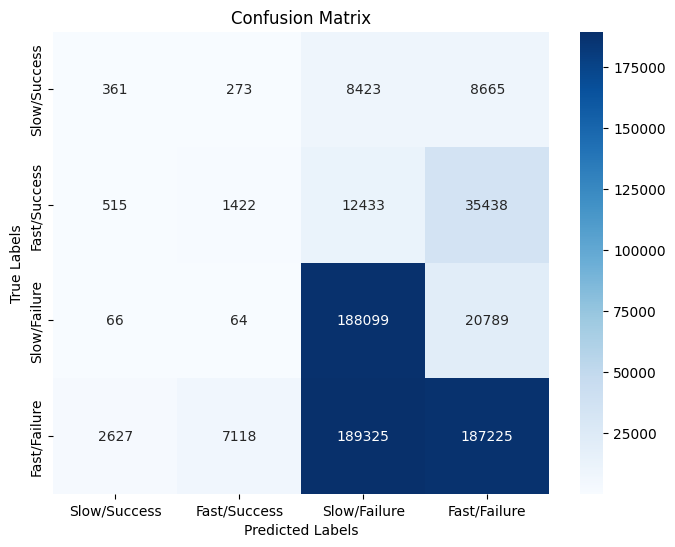

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
cm = confusion_matrix(y_true_indices, y_pred_indices)
# ConfusionMatrixDisplay(cm).plot()
CLIST = ["Slow/Success", "Fast/Success", "Slow/Failure", "Fast/Failure"]
# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
# 

In [44]:
total = np.sum(cm, axis=1)
print(total)
print(cm)

[ 17722  49808 209018 386295]
[[     9      0   7111  10602]
 [    26      1   9243  40538]
 [     1      0 177167  31850]
 [    59      0 154620 231616]]


In [22]:
for i in range(len([0,1,2,3,4]), 0, -1):
    print(i)

5
4
3
2
1
